In [ ]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt


import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from matplotlib import font_manager
#font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

In [139]:
#load data
df = pd.read_csv("country_lyrics.csv")

# make a list of words from the raw lyrics
def words_from_lyrics(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)   # keep only letters and spaces
    return text.split()

df["word_list"] = df["lyrics"].apply(words_from_lyrics)

#add ID column
df["ID"] = [i + 1 for i in df.reset_index()["index"]]
df.head()

#Add total song length
df["song_length"] = [len(i) for i in df["word_list"]]

#add common nouns (as identified via spaCy)
words_to_search = ['girl', 'baby', 'night', 'love', 'heart', 'song', 'tonight', 'town', 'road', 'home']

### Add counts of common words
for word in words_to_search:
    df[f"count_{word}"] = df['word_list'].apply(lambda x: x.count(word))

### get positions of common words
pos = []

for row_idx, row in df.iterrows():
    tokens = row["word_list"] if isinstance(row["word_list"], list) else []
    
    for word in words_to_search:
        positions = [i for i, token in enumerate(tokens) if token == word]
        if positions:
            pos.append({
                "ID": row["ID"],  
                "word": word,
                "positions": positions
            })

pos_df = pd.DataFrame(pos)
pos_df_pivot = pos_df.pivot(index="ID", columns="word", values="positions").reset_index()
df = pd.merge(df, pos_df_pivot, left_on="ID", right_on="ID", how="left", suffixes=("", "_pos") )

In [142]:
df["count_road"].sum()

157

In [7]:
df.describe()

,entered_top_30_in,rough_order,ID,song_length,count_girl,count_baby,count_night,count_love,count_heart,count_song,count_tonight,count_town,count_road,count_home
count,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000
mean,2016.297521,242.500000,242.500000,307.198347,1.613636,1.545455,0.935950,1.535124,0.601240,0.491736,0.685950,0.464876,0.324380,0.561983
std,1.772318,139.863028,139.863028,64.065523,3.658494,2.487234,1.599052,3.381965,1.310919,1.368809,2.296935,1.426170,1.051542,2.665297
min,2013.000000,1.000000,1.000000,122.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,121.750000,121.750000,266.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,242.500000,242.500000,305.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018.000000,363.250000,363.250000,349.000000,2.000000,2.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2019.000000,484.000000,484.000000,503.000000,52.000000,18.000000,10.000000,28.000000,11.000000,15.000000,24.000000,18.000000,14.000000,46.000000


## Data vis

In [8]:
df["song"][9]

"Chillin' It"

### Dots on spiral

In [143]:
def create_spiral_equal_arc(df, col_name='count', turns=7):
    n = len(df)
    values = df[col_name].values.astype(float)

    # Archimedean spiral sampling for even spacing
    a = 0.01
    b = 0.04

    theta_dense = np.linspace(0, 2 * np.pi * turns, 20000)
    r_dense = a + b * theta_dense

    dtheta = np.diff(theta_dense)
    drdtheta = np.full_like(r_dense[:-1], b)
    ds = np.sqrt(r_dense[:-1]**2 + drdtheta**2) * dtheta

    s = np.concatenate(([0], np.cumsum(ds)))
    s_target = np.linspace(0, s[-1], n)

    theta = np.interp(s_target, s, theta_dense)
    r = np.interp(s_target, s, r_dense)

    return theta, r, values

In [215]:
max_song_length = 503
word = "girl"

# Convert missing values to empty lists
df[word] = df[word].apply(lambda x: x if isinstance(x, list) else [])

# Build position frequency across all songs
counts_per_pos = {"pos": [], "count": []}

for i in range(max_song_length):
    counter = sum(1 for positions in df[word] if i in positions)
    counts_per_pos["pos"].append(i)
    counts_per_pos["count"].append(counter)

counts_df = pd.DataFrame(counts_per_pos)
counts_df["opacity"] = counts_df["opacity"] = [
    1.0 if i  >0 
    else 0.5
    for i in counts_df["count"]
]

max(counts_df["count"])

11

In [218]:
#COLORS
clrs = {"title" : "#451A14", "bg":"#C3CDD2"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#7f895a'), 
(p,  '#65764f'),
(0.4,  '#4d6244'),
(0.6,  '#384f39'),
(0.8, '#263c2d'),
(1.0,'#172a21'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')

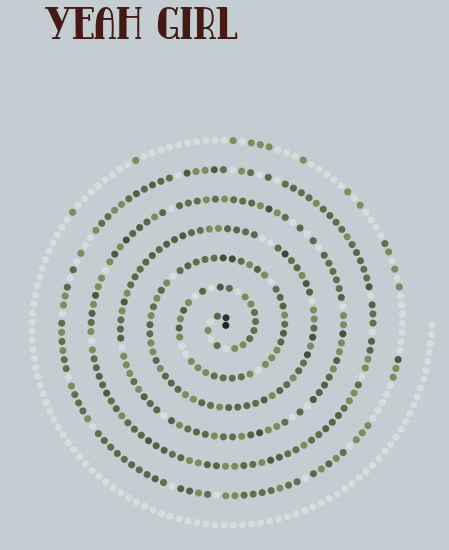

In [ ]:
#get positions for dots
theta, r, values = create_spiral_equal_arc(counts_df, col_name='count', turns=7)

# Create figure
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,8))
fig.set_facecolor(clrs["bg"])
ax.axis('off')

#plot dots along spiral
scatter = ax.scatter(
        theta,
        r,
        c=values,
        cmap=cmap,
        vmin=0,
        vmax=11,
        s=50,
        alpha=counts_df["opacity"],
       linewidth=0
    )

#add title
fig.text(0.2,1, "Yeah girl", color=clrs["title"], fontsize=40, fontproperties=title_font)
fig.text(0.2,1, "Yeah girl", color=clrs["title"], fontsize=40, fontproperties=title_font)

#legend


plt.show()

In [ ]:
#COLORS
clrs = {"title" : "#001920", "bg":"#C1D1D7"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#e58c75'), 
(p,  '#c96a54'),
(0.4,  '#ac4835'),
(0.6,  '#8a3122'),
(0.8, '#67251b'),
(1.0,'#451a14'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')

In [ ]:
#COLORS
clrs = {"title" : "#001920", "bg":"#C3CDD2"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#7f895a'), 
(p,  '#65764f'),
(0.4,  '#4d6244'),
(0.6,  '#384f39'),
(0.8, '#263c2d'),
(1.0,'#172a21'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')

In [ ]:
#COLORS
clrs = {"title" : "#cccccc", "bg":"#0E0821"}

#cmap
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#ff00ff'), 
(p,  '#ff33cc'),
(0.4,  '#ff6699'),
(0.6,  '#ff9966'),
(0.8, '#ffcc33'),
(1.0,'#ffff00'),
])

#FONTS
title_font = font_manager.FontProperties(fname='C:\\Users\\lisa.hornung\\AppData\\Local\\Microsoft\\Windows\\Fonts\\QuadSerif-vn3m4.ttf')

In [120]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Get the 'cool' colormap
cmap = plt.cm.spring

# Sample a few evenly spaced colors
num_colors = 6  #
sampled_colors = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Convert to hex codes
hex_codes = [mcolors.rgb2hex(color[:3]) for color in sampled_colors]

print(hex_codes)

['#ff00ff', '#ff33cc', '#ff6699', '#ff9966', '#ffcc33', '#ffff00']


In [105]:
#COLOR SCALE
vmin = 0
threshold = 1
vmax = 11

# Position of threshold on the min-max scale
p = (threshold - vmin) / (vmax - vmin)

cmap = mcolors.LinearSegmentedColormap.from_list(
"custom",
[(0, "#ececec"),  
(p,  '#015883'), 
(p,  '#04739e'),
(0.4,  '#1190b8'),
(0.6,  '#24aed0'),
(0.8, '#3bcce7'),
(1.0,'#56ebfc'),
])

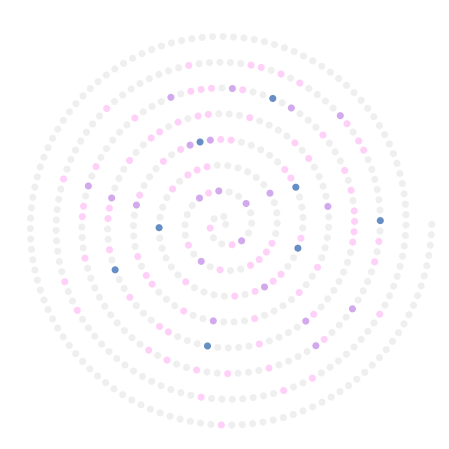

In [48]:
def create_spiral_equal_arc(df, col_name='count', turns=8, cmap=cmap):
    n = len(df)
    values = df[col_name].values.astype(float)

    # Archimedean spiral sampling for even spacing
    a = 0.01
    b = 0.04

    theta_dense = np.linspace(0, 2 * np.pi * turns, 20000)
    r_dense = a + b * theta_dense

    dtheta = np.diff(theta_dense)
    drdtheta = np.full_like(r_dense[:-1], b)
    ds = np.sqrt(r_dense[:-1]**2 + drdtheta**2) * dtheta

    s = np.concatenate(([0], np.cumsum(ds)))
    s_target = np.linspace(0, s[-1], n)

    theta = np.interp(s_target, s, theta_dense)
    r = np.interp(s_target, s, r_dense)

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,8))
    scatter = ax.scatter(
        theta,
        r,
        c=values,
        cmap=cmap,
        s=50,
        alpha=df["opacity"],
       linewidth=0
    )
    ax.axis('off')
    plt.show()

create_spiral_equal_arc(counts_df, col_name='count', turns=8)

## Exploration

### Identify most common nouns using SpaCy

In [115]:
import spacy

nlp = spacy.load("en_core_web_sm")

def get_noun_tokens(text):
    doc = nlp(str(text))
    nouns = []
    for token in doc:
        if token.pos_ in {"NOUN", "PROPN"} and not token.is_stop and token.is_alpha:
            nouns.append(token.lemma_.lower())
    return nouns

df["noun_tokens"] = df["lyrics"].apply(get_noun_tokens)

noun_counts = (
    df
    .explode("noun_tokens")
    .dropna(subset=["noun_tokens"])
    .groupby("noun_tokens", as_index=False)
    .size()
    .rename(columns={"noun_tokens": "word", "size": "mentions"})
    .sort_values("mentions", ascending=False)
    .reset_index(drop=True)
)

noun_counts.head(20)

,word,mentions
0,girl,876
1,baby,760
2,time,561
3,night,515
4,way,418
5,love,392
6,heart,337
7,tonight,333
8,thing,285
9,song,280


### Prepare for vis

In [46]:

# Example output
word_positions

{'girl': [],
 'baby': [],
 'night': [],
 'love': [],
 'heart': [],
 'song': [],
 'tonight': [],
 'town': [],
 'road': [],
 'home': []}

In [40]:
df.describe()

,song,entered_top_30_in,rough_order,girl,baby,night,love,heart,tonight,town,road,home
count,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000,484.000000
mean,0.586777,2016.297521,242.500000,1.811983,1.570248,1.064050,1.595041,0.700413,0.688017,0.483471,0.384298,0.561983
std,1.449891,1.772318,139.863028,3.833461,2.494139,1.694599,3.411899,1.363196,2.296766,1.475029,1.229823,2.665297
min,0.000000,2013.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2015.000000,121.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,2016.000000,242.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,2018.000000,363.250000,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,15.000000,2019.000000,484.000000,52.000000,18.000000,10.000000,28.000000,11.000000,24.000000,18.000000,14.000000,46.000000


## Visualisation


## Playground

Unused code

### Use NLTK Tokens

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter

# NLTK setup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize

# Download resources (run once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # improves lemmatization

In [ ]:
def clean_and_tokenize(text):
    """
    Clean text and return tokens
    """

    lemmatizer = WordNetLemmatizer()

    # Lowercase
    text = text.lower()
    
    # Split hyphenated words
    text = re.sub(r'-', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    if 'ai' in stop_words:
        print("AI is being removed as a stopword")
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Optional: remove very short words
    tokens = [word for word in tokens if len(word) >= 2]

    return tokens

df["tokens"] = [clean_and_tokenize(text) for text in df["lyrics"]]

counts = df.copy()

#find words in tokens
counts["total_tokens"] = [len(i) for i in counts["tokens"]]
words_to_search = ['truck', 'love', 'girl', 'beer', 'road', '']
for word in words_to_search:
    counts[word] = counts['tokens'].apply(lambda x: x.count(word))

counts[words_to_search].sum()


In [ ]:
# Count how many times each word appears in the cleaned "tokens" column
word_counts = (
    df
    .explode("tokens")                  # one row per token
    .dropna(subset=["tokens"])         # remove missing values
    .groupby("tokens", as_index=False)
    .size()
    .rename(columns={"tokens": "word", "size": "mentions"})
    .sort_values("mentions", ascending=False)
)

# Pivot-style table with all words and the number of mentions
word_pivot = (
    word_counts
    .pivot_table(index="word", values="mentions", aggfunc="sum")
    .reset_index()
)

word_pivot.sort_values(by="mentions" ,ascending=False).head(50)